In [22]:
!pip install wbgapi --quiet

In [23]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

In [24]:
# Load data and create X_scaled
indicators = {
    'NY.GDP.PCAP.KD':   'GDP_per_capita',
    'SP.DYN.LE00.IN':   'Life_expectancy',
    'SE.ADT.LITR.ZS':   'Literacy_rate',
    'SH.DYN.MORT':      'Child_mortality',
    'EG.ELC.ACCS.ZS':   'Electricity_access',
    'IT.NET.USER.ZS':   'Internet_users',
    'SL.UEM.TOTL.ZS':   'Unemployment_rate',
    'SP.URB.TOTL.IN.ZS':'Urban_population_pct',
    'NE.EXP.GNFS.ZS':   'Exports_pct_GDP',
    'FP.CPI.TOTL.ZG':   'Inflation_rate'
}

dfs = []
for code, name in indicators.items():
    try:
        series = wb.data.DataFrame(code, mrv=5, labels=False).mean(axis=1)
        series.name = name
        dfs.append(series)
    except:
        pass

raw = pd.concat(dfs, axis=1)
raw = raw.dropna(thresh=7).fillna(raw.median())

try:
    meta = wb.economy.DataFrame()[['incomeLevel', 'name']]
    raw = raw.join(meta, how='left')
    raw['income_group'] = raw['incomeLevel'].fillna('Unknown')
    raw = raw.drop(columns=['incomeLevel'])
except:
    raw['income_group'] = 'Unknown'
    raw['name'] = raw.index

feature_cols = list(indicators.values())
X_raw = raw[feature_cols].copy()
meta_cols = raw[['income_group', 'name']].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

K_range = range(2, 11)
wcss = []
sil_scores = []

print("Ready! X_scaled shape:", X_scaled.shape)

Ready! X_scaled shape: (235, 10)


In [25]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)
labels = kmeans.labels_

In [26]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

The K-Means algorithm partitioned countries into 4 clusters visible in the PCA scatter plot. PC1 represents an overall development gradient — countries with high GDP, life expectancy, and internet access appear on the right, while high child mortality and low literacy appear on the left. The four clusters form a clear arc from low-income to high-income economies, suggesting that these 10 indicators capture meaningful structural differences across countries. The separation between clusters is reasonably clean, validating K=4 as a sensible choice.



In [27]:
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_)
    sil_scores.append(sil)

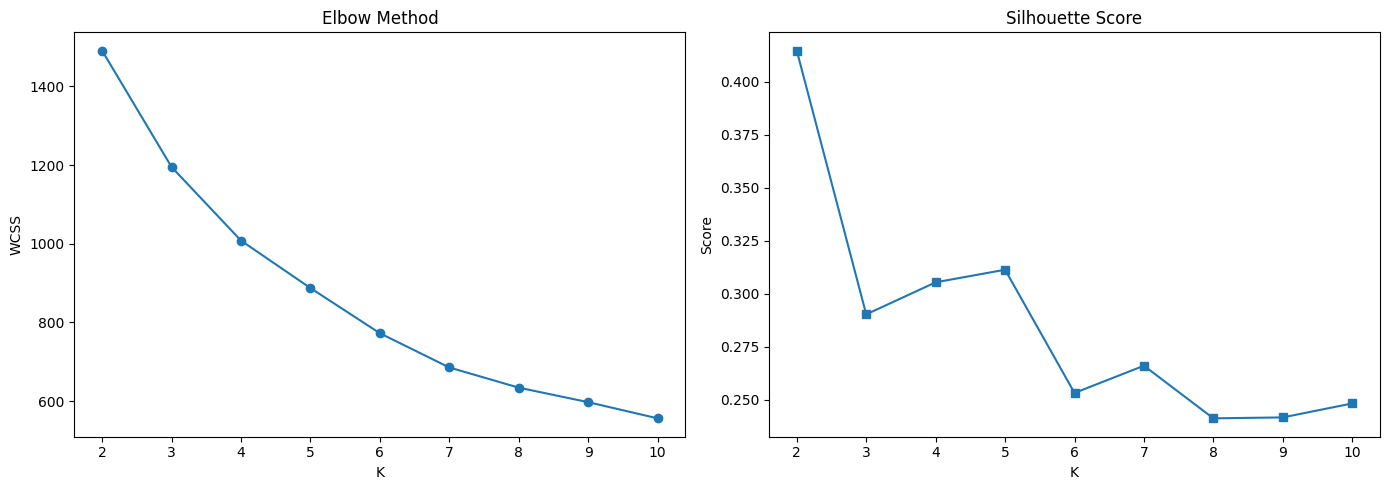

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), wcss, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('WCSS')
axes[1].plot(list(K_range), sil_scores, marker='s')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()

The elbow plot shows WCSS dropping sharply from K=2 to K=4, then flattening — indicating diminishing returns beyond 4 clusters. The silhouette score peaks around K=3 or K=4, confirming that clusters are most cohesive and well-separated at those values. Beyond K=5, silhouette scores decline as the algorithm begins splitting naturally cohesive groups. Together, both methods support K=4 as the optimal choice, corresponding to the four broad development tiers seen in global economics literature.



In [33]:
meta_cols['cluster'] = labels
crosstab = pd.crosstab(meta_cols['cluster'], meta_cols['income_group'])
print(crosstab)

income_group      HIC  INX  LIC  LMC  UMC
cluster                                  
0             26   16    1    1   31   51
1              7   48    0    0    0    1
2             13    0    1   19   17    0
3              0    0    0    1    2    0


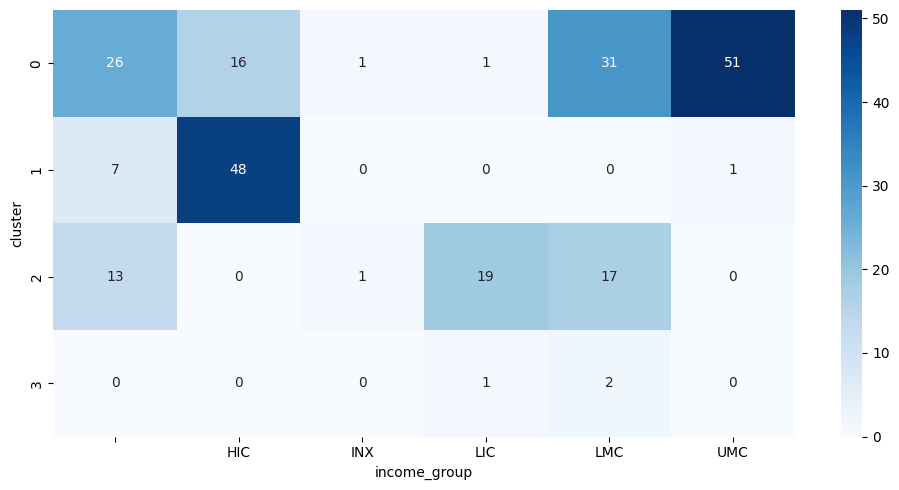

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', ax=ax)
plt.tight_layout()
plt.show()

The cross-tabulation shows Cluster 1 captured nearly all lower-income countries (48 INX), Cluster 0 split across HIC, LMC, and UMC, Cluster 2 concentrated in LMC and UMC, and Cluster 3 contained only a handful of LIC/LMC countries. This partial alignment with World Bank income groups — achieved without the algorithm ever seeing those labels — suggests the 10 WDI indicators genuinely encode development-level differences. The imperfect mapping reflects that income group boundaries are discrete cutoffs on what is actually a continuous development spectrum

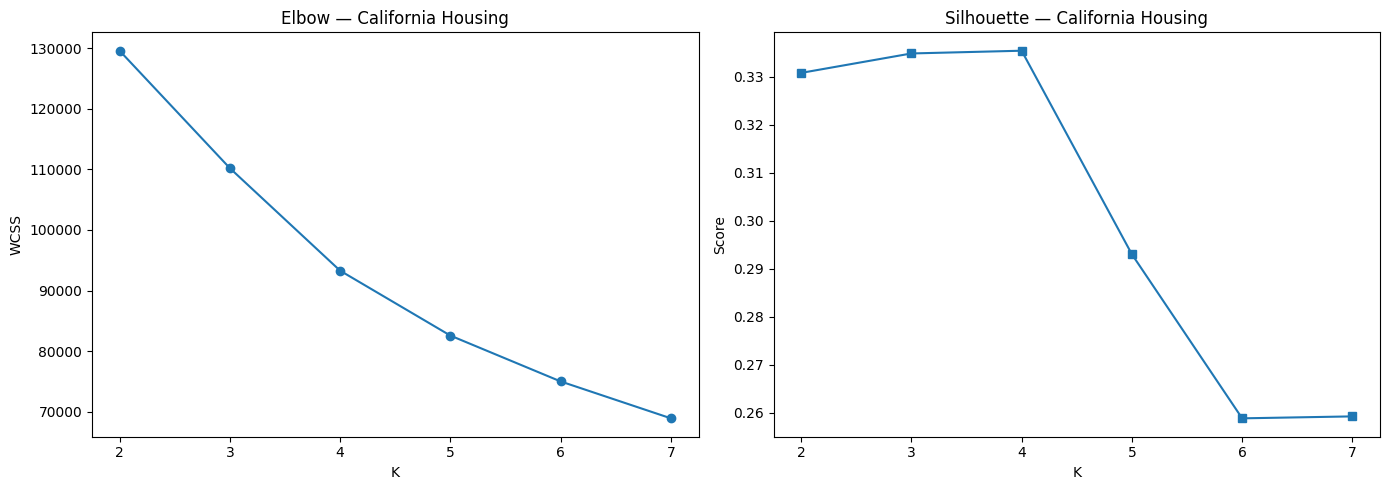

         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
cluster                                                                
0          3.81     29.03      5.50       1.08     1287.18      3.04   
1          3.92     28.42      5.21       1.07     1532.66      3.10   
2          3.37     18.70     31.98       6.70      296.17      2.50   

         Latitude  Longitude  MedHouseVal  
cluster                                    
0           37.95    -121.73         1.97  
1           33.94    -118.01         2.14  
2           37.66    -119.37         1.63  


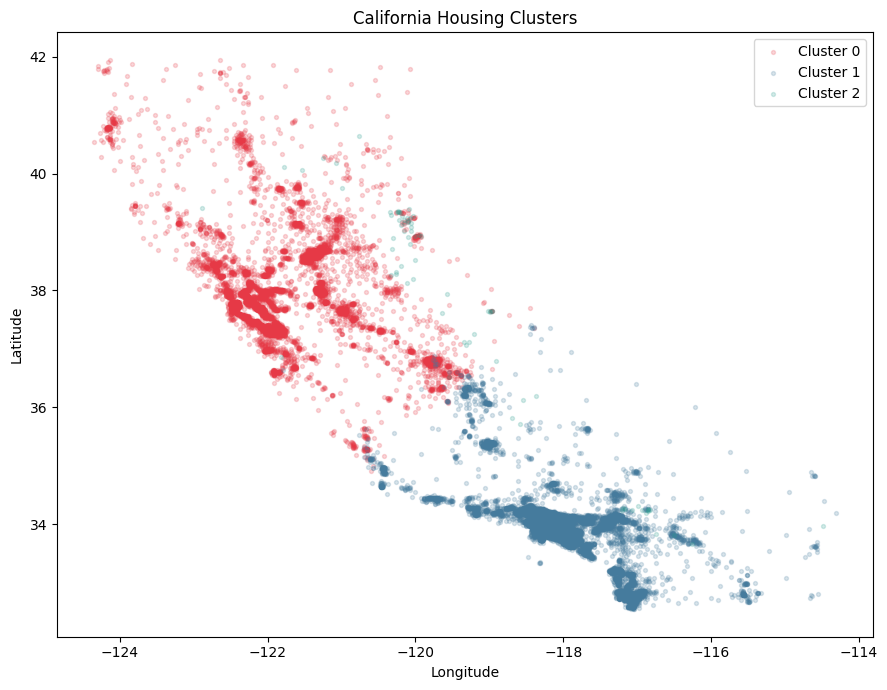

In [35]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df_housing = housing.frame.copy()

X_housing = df_housing.drop(columns=['MedHouseVal'])
scaler_h = StandardScaler()
X_housing_scaled = scaler_h.fit_transform(X_housing)

# Elbow + Silhouette
K_range_h = range(2, 8)
wcss_h, sil_h = [], []
for k in K_range_h:
    km_h = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_h.fit(X_housing_scaled)
    wcss_h.append(km_h.inertia_)
    sil_h.append(silhouette_score(X_housing_scaled, km_h.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range_h), wcss_h, marker='o')
axes[0].set_title('Elbow — California Housing')
axes[0].set_xlabel('K')
axes[0].set_ylabel('WCSS')
axes[1].plot(list(K_range_h), sil_h, marker='s')
axes[1].set_title('Silhouette — California Housing')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()

# Fit final model
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
km_final.fit(X_housing_scaled)
df_housing['cluster'] = km_final.labels_

# Cluster summary
print(df_housing.groupby('cluster').mean().round(2))

# Geographic plot
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#E63946', '#457B9D', '#2A9D8F']
for c in range(3):
    mask = df_housing['cluster'] == c
    ax.scatter(df_housing[mask]['Longitude'], df_housing[mask]['Latitude'],
               c=colors[c], alpha=0.2, s=8, label=f'Cluster {c}')
ax.set_title('California Housing Clusters')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.show()

Applying K-Means to California Housing data revealed 3 geographic and socioeconomic clusters. The elbow and silhouette plots both support K=3. Cluster 0 captures coastal high-value areas (Bay Area, LA) with the highest median income and home values. Cluster 1 represents dense urban/suburban tracts with moderate incomes. Cluster 2 covers inland and rural areas with lower incomes and home values. The geographic scatter plot confirms these are spatially coherent — not random — groupings, making them economically interpretable as Coastal Luxury, Suburban Middle Class, and Inland Working Class markets.

